# Mini Project 1

## Research Question

Are there differences in word frequencies between works by the same author and works by different authors?

## Data Source

I will use books from Project Gutenberg. I will compare Pride and Prejudice and Emma by Jane Austen, same with Adventures of Huckleberry Finn by Mark Twain.

## Approach

I will clean the text from each book and calculate the frequency of words used in each work. First, I will compare Pride and Prejudice and Emma to see how word usage compares between two works by the same author. Then, I will compare Jane Austen's writing with Mark Twain's writing to identify differences in their word usage.

## Goal

The goal is to see whether word frequency can reveal patterns in an author's writing style and identify words that one author uses more frequently than another.

In [1]:
import requests
import re
from collections import Counter
import matplotlib.pyplot as plt

In [2]:
urls = {
    "Pride and Prejudice": "https://www.gutenberg.org/files/1342/1342-0.txt",
    "Emma": "https://www.gutenberg.org/files/158/158-0.txt",
    "Huckleberry Finn": "https://www.gutenberg.org/files/76/76-0.txt"
}

texts = {}

for book, url in urls.items():
    response = requests.get(url)
    response.raise_for_status()
    texts[book] = response.text

    print(book, "-", len(response.text), "characters")

Pride and Prejudice - 728846 characters
Emma - 880527 characters
Huckleberry Finn - 571153 characters


In [ ]:
stop_words = {
    "the", "and", "a", "an", "of", "to", "in", "that", "it",
    "is", "was", "for", "with", "as", "at", "by", "on", "be",
    "this", "from", "or", "but"
}

def get_word_frequencies(text):
    text = text.lower()

    words = re.findall(r"[a-z']+", text)

    words = [word for word in words if word not in stop_words]

    frequencies = Counter(words)

    return frequencies, len(words)

In [4]:
book_data = {}

for book, text in texts.items():
    frequencies, total_words = get_word_frequencies(text)

    book_data[book] = {
        "frequencies": frequencies,
        "total_words": total_words
    }

    print(book, "-", total_words, "regular words")

Pride and Prejudice - 92246 regular words
Emma - 117421 regular words
Huckleberry Finn - 85101 regular words


In [5]:
pp = book_data["Pride and Prejudice"]["frequencies"]
emma = book_data["Emma"]["frequencies"]

print("Pride and Prejudice:")
print(pp.most_common(15))

print("\nEmma:")
print(emma.most_common(15))

Pride and Prejudice:
[('her', 2284), ('i', 2122), ('she', 1751), ('not', 1500), ('you', 1376), ('he', 1358), ('his', 1303), ('had', 1186), ('have', 879), ('mr', 808), ('him', 777), ('my', 728), ('s', 672), ('all', 651), ('elizabeth', 645)]

Emma:
[('i', 3196), ('her', 2489), ('she', 2364), ('not', 2151), ('you', 1999), ('he', 1811), ('had', 1626), ('have', 1321), ('very', 1212), ('mr', 1154), ('his', 1150), ('so', 974), ('s', 933), ('emma', 865), ('all', 848)]


In [6]:
def plot_top_words(frequencies, title, n=15):
    top_words = frequencies.most_common(n)

    words = [word for word, count in top_words]
    counts = [count for word, count in top_words]

    plt.figure(figsize=(10, 6))
    plt.barh(words[::-1], counts[::-1])
    plt.xlabel("Frequency")
    plt.ylabel("Word")
    plt.title(title)
    plt.show()

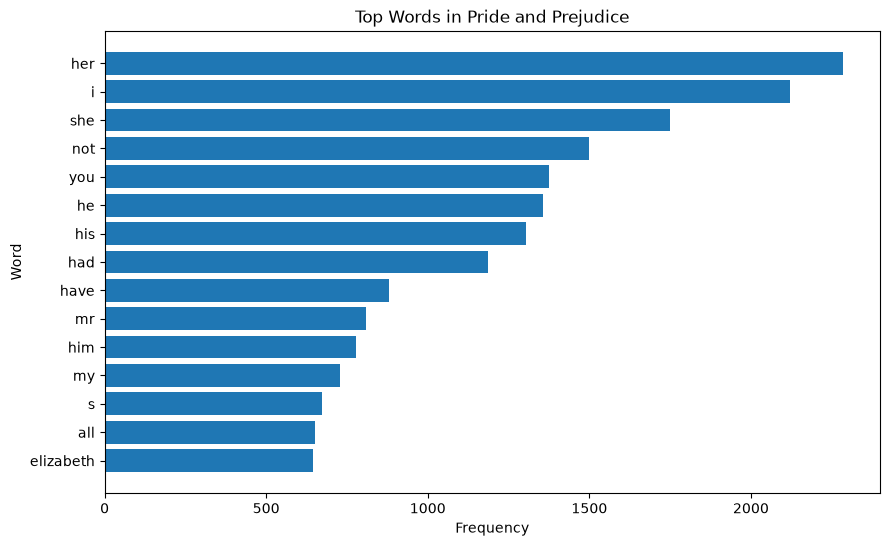

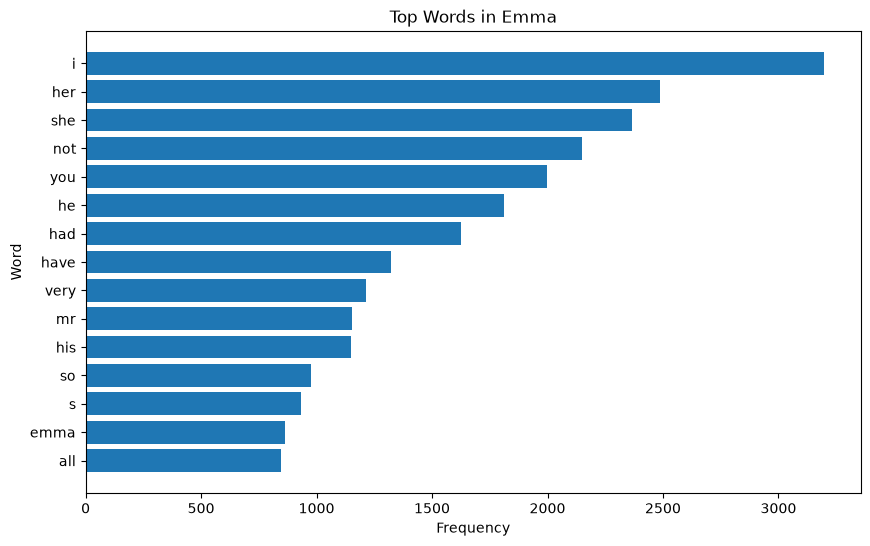

In [7]:
plot_top_words(pp, "Top Words in Pride and Prejudice")
plot_top_words(emma, "Top Words in Emma")

## Same Author Results

The word frequencies in Pride and Prejudice and Emma show several similarities. Words such as "her," "I," "she," "not," "you," "he," "had," "have," and "Mr" appear to be the most frequent words in both books. This says that the two works share similar patterns in word usage.

There are also some differences. For example, "very" and "so" appear as the most frequent words in Emma, while they don't appear in the top 15 for Pride and Prejudice. Character names also appear frequently, with "Elizabeth" in Pride and Prejudice and "Emma" in Emma.

In [8]:
def relative_frequency(word, frequencies, total_words):
    return frequencies[word] / total_words

huck = book_data["Huckleberry Finn"]["frequencies"]

pp_total = book_data["Pride and Prejudice"]["total_words"]
huck_total = book_data["Huckleberry Finn"]["total_words"]

common_words = set(pp.keys()) & set(huck.keys())

comparison = []

for word in common_words:
    austen_freq = relative_frequency(word, pp, pp_total)
    twain_freq = relative_frequency(word, huck, huck_total)

    comparison.append((word, austen_freq, twain_freq))

comparison[:10]



[('admission', 1.0840578453266267e-05, 3.525222970352875e-05),
 ('generous', 0.00014092751989246147, 4.700297293803833e-05),
 ('past', 0.00010840578453266266, 0.000141008918814115),
 ('draw', 6.50434707195976e-05, 1.1750743234509583e-05),
 ('train', 1.0840578453266267e-05, 1.1750743234509583e-05),
 ('parent', 1.0840578453266267e-05, 1.1750743234509583e-05),
 ('fill', 1.0840578453266267e-05, 1.1750743234509583e-05),
 ('gentle', 6.50434707195976e-05, 9.400594587607666e-05),
 ('disappoint', 2.1681156906532534e-05, 1.1750743234509583e-05),
 ('wandering', 3.25217353597988e-05, 1.1750743234509583e-05)]

In [9]:
differences = []

for word in common_words:
    austen_freq = relative_frequency(word, pp, pp_total)
    twain_freq = relative_frequency(word, huck, huck_total)

    difference = austen_freq - twain_freq

    differences.append((word, austen_freq, twain_freq, difference))

austen_words = sorted(
    differences,
    key=lambda x: x[3],
    reverse=True
)

print("Words used more frequently by Austen:")

for word, austen_freq, twain_freq, difference in austen_words[:15]:
    print(
        word,
        "Austen:", round(austen_freq * 100, 3), "%",
        "Twain:", round(twain_freq * 100, 3), "%"
    )


twain_words = sorted(
    differences,
    key=lambda x: x[3]
)

print("Words used more frequently by Twain:")

for word, austen_freq, twain_freq, difference in twain_words[:15]:
    print(
        word,
        "Austen:", round(austen_freq * 100, 3), "%",
        "Twain:", round(twain_freq * 100, 3), "%"
    )

Words used more frequently by Austen:
her Austen: 2.476 % Twain: 0.417 %
not Austen: 1.626 % Twain: 0.194 %
she Austen: 1.898 % Twain: 0.646 %
mr Austen: 0.876 % Twain: 0.027 %
his Austen: 1.413 % Twain: 0.664 %
had Austen: 1.286 % Twain: 0.544 %
have Austen: 0.953 % Twain: 0.212 %
were Austen: 0.618 % Twain: 0.011 %
which Austen: 0.616 % Twain: 0.136 %
very Austen: 0.546 % Twain: 0.118 %
been Austen: 0.581 % Twain: 0.16 %
will Austen: 0.464 % Twain: 0.073 %
mrs Austen: 0.384 % Twain: 0.009 %
am Austen: 0.361 % Twain: 0.026 %
are Austen: 0.401 % Twain: 0.072 %
Words used more frequently by Twain:
t Austen: 0.023 % Twain: 2.496 %
i Austen: 2.3 % Twain: 4.318 %
up Austen: 0.125 % Twain: 1.023 %
we Austen: 0.288 % Twain: 1.13 %
out Austen: 0.156 % Twain: 0.984 %
says Austen: 0.016 % Twain: 0.75 %
he Austen: 1.472 % Twain: 2.195 %
got Austen: 0.027 % Twain: 0.733 %
s Austen: 0.728 % Twain: 1.334 %
then Austen: 0.192 % Twain: 0.705 %
down Austen: 0.086 % Twain: 0.57 %
so Austen: 0.658 % Twa

## Preferred Words Between Authors

The results show clear differences in word usage between Jane Austen and Mark Twain. Austen uses words such as "her," "she," "Mr," "Mrs," and "very" more frequently. For example, "her" makes up about 2.48% of the words analyzed in Pride and Prejudice, compared with only 0.42% in Huckleberry Finn.

Mark Twain uses words such as "I," "we," "says," "got," "then," and "see" more frequently. For example, "says" appears at a frequency of about 0.75% in Huckleberry Finn, compared with only 0.02% in Pride and Prejudice.

These results show that there are words preferred more strongly in one author's work than in the other's.

# Extra Credit

In [10]:
word = "very"

for book in ["Pride and Prejudice", "Emma", "Huckleberry Finn"]:
    count = book_data[book]["frequencies"][word]
    total = book_data[book]["total_words"]
    p = count / total

    print(
        book,
        "- Count:", count,
        "- Total words:", total,
        "- Frequency:", round(p * 100, 3), "%"
    )

Pride and Prejudice - Count: 504 - Total words: 92246 - Frequency: 0.546 %
Emma - Count: 1212 - Total words: 117421 - Frequency: 1.032 %
Huckleberry Finn - Count: 100 - Total words: 85101 - Frequency: 0.118 %


In [ ]:
pip install statsmodels

In [14]:
from statsmodels.stats.proportion import proportions_ztest


count_pp = pp[word]
count_emma = emma[word]

total_pp = book_data["Pride and Prejudice"]["total_words"]
total_emma = book_data["Emma"]["total_words"]

counts = [count_pp, count_emma]
totals = [total_pp, total_emma]

z_stat, p_value = proportions_ztest(counts, totals)

print("Pride and Prejudice:", count_pp / total_pp)
print("Emma:", count_emma / total_emma)
print("Z-statistic:", z_stat)
print("P-value:", p_value)

Pride and Prejudice: 0.005463651540446198
Emma: 0.01032183340288364
Z-statistic: -12.255931344829651
P-value: 1.5614503796533602e-34


### Same Author Comparison

For the word "very," the estimated frequency was about 0.546% in Pride and Prejudice and 1.032% in Emma. The two-proportion z-test produced a p-value of approximately 1.56 × 10^-34, which is much smaller than 0.05.

This shows that the difference in the frequency of "very" between the two books is statistically significant. Even though both books were written by Jane Austen, "very" appears proportionally more often in Emma than in Pride and Prejudice.